# **CUSTOMER SEGMENTATION USING BOLTZMANN MACHINE:**

**Introduction :**

This activity focuses on customer segmentation using a Boltzmann Machine based on online retail shopping data. The dataset contains transaction records of customers, including products purchased, quantity, and purchase details. The main objective is to analyze customer buying behavior and identify hidden patterns using a machine learning model.

In this project, the data is first cleaned and preprocessed, then transformed into a binary format representing whether a customer purchased a product or not. A Restricted Boltzmann Machine (RBM) is then trained on this data to learn the underlying probability distribution of customer purchases. This helps in grouping customers with similar shopping habits and can be useful for recommendation systems and targeted marketing.

**Task 1: Data Loading & Cleaning bold text**

In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Online Retail.xlsx')

# Display first 5 rows
print(df.head())

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Remove missing values
df.dropna(inplace=True)

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("\nCleaned Data Shape:", df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country          

**Task 2: Preprocessing**

In [3]:
# (a) Encode Categorical Data
# Convert non-numeric data into numeric form

# Select relevant columns
df = df[['CustomerID', 'StockCode', 'Quantity']]

# Convert Customer ID to integer
df['CustomerID'] = df['CustomerID'].astype(int)


# (b) Scale Numerical Features
# Normalize values between 0 and 1

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Quantity'] = scaler.fit_transform(df[['Quantity']])

print(df.head())

   CustomerID StockCode  Quantity
0       17850    85123A  0.000062
1       17850     71053  0.000062
2       17850    84406B  0.000086
3       17850    84029G  0.000062
4       17850    84029E  0.000062


**Task 3: Data Transformation**

In [4]:
# Convert data into customer-product matrix.

# A) Create Matrix

# Create pivot table
customer_product = df.pivot_table(
    index='CustomerID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum'
)

# Replace missing values with 0
customer_product.fillna(0, inplace=True)

print(customer_product.head())


# B) Convert to Binary Format

# Convert to binary
customer_product_binary = customer_product.copy()

customer_product_binary[customer_product_binary > 0] = 1

# Convert to array
data = customer_product_binary.values

print("Binary Matrix Shape:", data.shape)

StockCode   10002  10080  10120  10125  10133  10135  11001  15030  15034  \
CustomerID                                                                  
12346         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
12347         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
12348         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
12349         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
12350         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   

StockCode   15036  ...  90214V  90214W  90214Y  90214Z  BANK CHARGES   C2  \
CustomerID         ...                                                      
12346         0.0  ...     0.0     0.0     0.0     0.0           0.0  0.0   
12347         0.0  ...     0.0     0.0     0.0     0.0           0.0  0.0   
12348         0.0  ...     0.0     0.0     0.0     0.0           0.0  0.0   
12349         0.0  ...     0.0     0.0     0.0     0.0           0.0  0.0  

**Task 4: Model Training (Boltzmann Machine)**

RBM Model Trained Successfully!
Sample Hidden Features:
 [[9.99507991e-01 9.99442492e-01 9.98474865e-01 9.99481675e-01
  9.99482731e-01 9.99395401e-01 9.99402762e-01 9.99503933e-01
  9.99458542e-01 9.99239892e-01 9.99493747e-01 9.99268751e-01
  9.99468169e-01 9.99462492e-01 9.99476543e-01 9.99472431e-01
  9.99431849e-01 9.99477810e-01 9.99454335e-01 9.98911156e-01
  9.99467579e-01 9.99426732e-01 9.99414134e-01 9.99418481e-01
  9.99443820e-01 9.99489121e-01 9.97785979e-01 9.99418480e-01
  9.99483527e-01 9.99157150e-01 9.99298189e-01 9.99477723e-01
  9.99473471e-01 9.99425355e-01 9.99380469e-01 9.98825186e-01
  9.99489386e-01 9.99277188e-01 9.99066879e-01 9.97870705e-01
  9.99243314e-01 9.99272566e-01 9.99339032e-01 9.99199206e-01
  9.99257767e-01 9.99483097e-01 9.99440542e-01 9.99483232e-01
  9.99486093e-01 9.99450226e-01 9.99287152e-01 9.99311818e-01
  9.99468637e-01 9.99074430e-01 9.99359083e-01 9.99430523e-01
  9.99437874e-01 9.99455983e-01 9.99484787e-01 9.99446898e-01
  9.99442813e

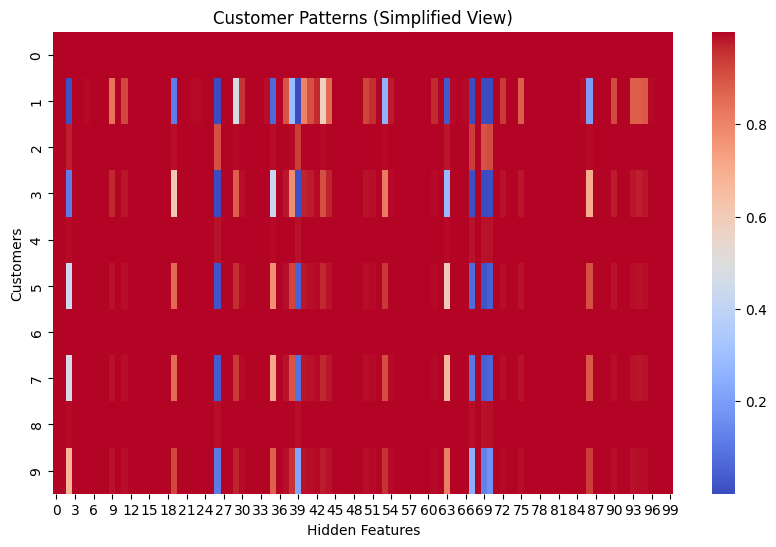

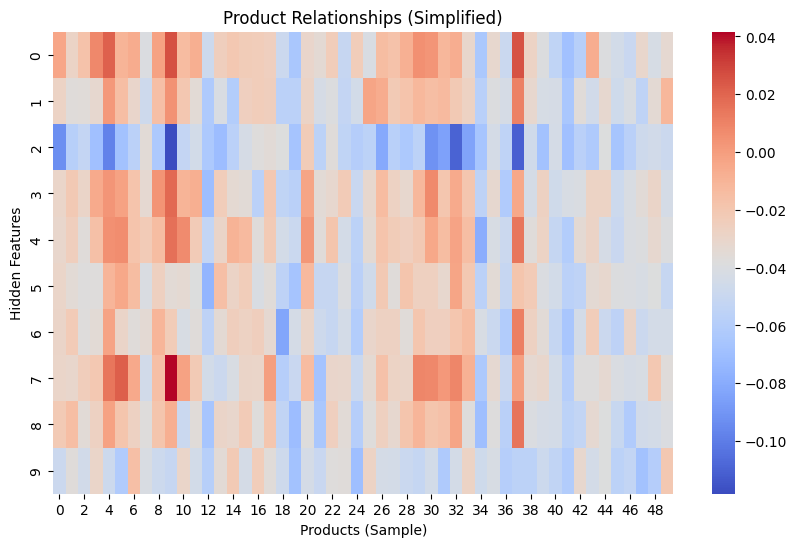

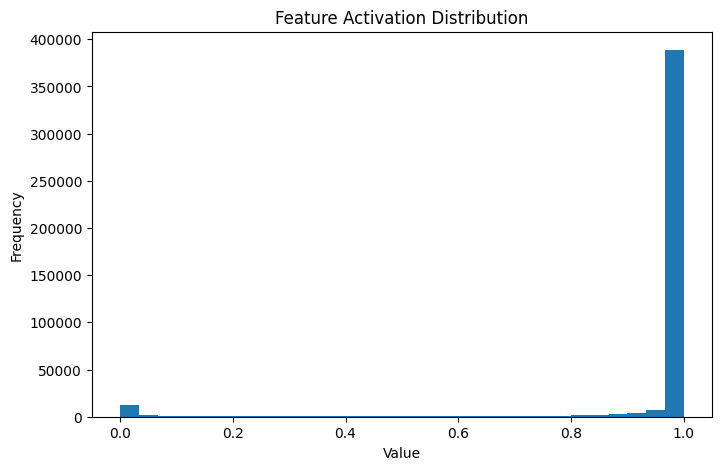

In [5]:
# A) Train RBM to learn hidden patterns.

from sklearn.neural_network import BernoulliRBM

# Initialize RBM
rbm = BernoulliRBM(
    n_components=100,
    learning_rate=0.01,
    n_iter=10,
    random_state=0
)

# Train model
rbm.fit(data)

print("RBM Model Trained Successfully!")



# B)Extract Learned Features

# Transform data into hidden features
hidden_features = rbm.transform(data)

print("Sample Hidden Features:\n", hidden_features[:5])



# C) Visualzation

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(hidden_features[:10], cmap='coolwarm')
plt.title("Customer Patterns (Simplified View)")
plt.xlabel("Hidden Features")
plt.ylabel("Customers")
plt.show()


plt.figure(figsize=(10,6))
sns.heatmap(rbm.components_[:10, :50], cmap='coolwarm')
plt.title("Product Relationships (Simplified)")
plt.xlabel("Products (Sample)")
plt.ylabel("Hidden Features")
plt.show()



plt.figure(figsize=(8,5))
plt.hist(hidden_features.flatten(), bins=30)
plt.title("Feature Activation Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [6]:
#Final Outputs

print("Final Cleaned Data Shape:", df.shape)
print("Binary Matrix Shape:", data.shape)
print("Hidden Feature Shape:", hidden_features.shape)

Final Cleaned Data Shape: (397924, 3)
Binary Matrix Shape: (4339, 3665)
Hidden Feature Shape: (4339, 100)


## Observations and Conclusion

### Observations

1.  **Data Loading & Cleaning:** Initial data cleaning involved handling missing values and removing invalid quantity entries, resulting in a dataset of `397924` rows and `8` columns, later refined to `3` relevant columns (`CustomerID`, `StockCode`, `Quantity`).
2.  **Preprocessing:** Customer IDs were successfully converted to integers, and the `Quantity` feature was scaled using `MinMaxScaler`.
3.  **Data Transformation:** A customer-product matrix was created and binarized, representing whether a customer purchased a product or not. The final binary matrix had a shape of `(4339, 3665)`, indicating `4339` unique customers and `3665` unique products.
4.  **Model Training & Feature Extraction:** A Bernoulli Restricted Boltzmann Machine (RBM) was successfully trained on the binary data, extracting `100` hidden features (`(4339, 100)`), which represent the underlying customer buying patterns. Visualizations of these hidden features and product relationships provide insights into customer behavior.

### Conclusion

This project successfully demonstrated how to perform customer segmentation using a Bernoulli Restricted Boltzmann Machine (RBM) on online retail data. We covered data loading, cleaning, preprocessing, and transformation into a binary customer-product matrix. The RBM model was then trained to extract hidden features representing customer buying patterns, which can be valuable for targeted marketing and recommendation systems.